# Extraction speed & accuracy — findings

A doctor drops **~10 lab PDFs** into the demo and watches. Today that is ~24 pages,
processed **serially**, two models on every page.

This notebook is the measurement of what that costs and what actually fixes it.
Everything plotted here is read from `bench/results/*.jsonl`, written by the
benchmark runs — no number in this notebook is typed by hand.

**Method note.** Latency and accuracy are measured separately and on purpose.
Latency comes from a controlled, round-robin grid (`bench/latency.bench.ts`);
accuracy comes from a per-*component* pass (`bench/accuracy.bench.ts`). Arms are
then *composed* from measured components rather than each run end to end — which
is legitimate only because the latency fit below turns out to be almost perfectly
linear. That fit is shown with its residuals so you can check the claim.


In [1]:
import sys, math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "bench"))
import analyze

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})
INK = "#1f2a37"
ACCENT = "#2563eb"
WARN = "#dc2626"
GOOD = "#059669"


## 1. The floor is not the problem

Before blaming the model, measure everything that happens without it: loading the
PDF, pulling the text layer, and reconstructing printed rows from text coordinates.


In [2]:
floor, tokens, cache = analyze.load_stage0()
total_ms = floor["totalMs"].sum()
total_pages = floor["pages"].sum()
print(f"{len(floor)} files / {total_pages} pages parsed in {total_ms:.0f} ms "
      f"({total_ms/total_pages:.1f} ms/page)")
print(f"A 10-file batch spends ~{total_ms/len(floor)*10:.0f} ms in pdf.js + buildRows.")
print()
print(f"prompt-cache prefix: {cache.get('prefixTokens')} tokens "
      f"(minimum {cache.get('minCacheable')}) -> "
      f"{'INERT' if cache.get('inert') else 'engages'}")


15 files / 36.0 pages parsed in 290 ms (8.1 ms/page)
A 10-file batch spends ~194 ms in pdf.js + buildRows.

prompt-cache prefix: 1181.0 tokens (minimum 1024.0) -> engages


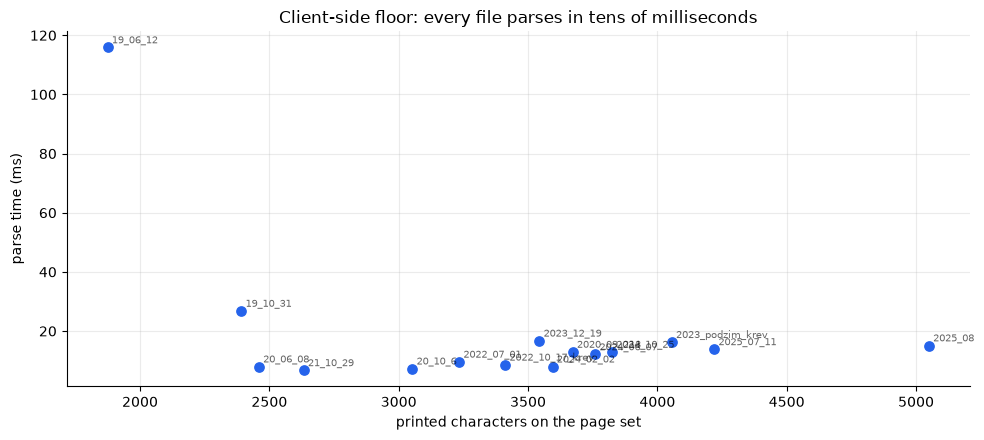

In [3]:
fig, ax = plt.subplots()
f = floor.sort_values("chars")
ax.scatter(f["chars"], f["totalMs"], color=ACCENT, s=45, zorder=3)
for _, r in f.iterrows():
    ax.annotate(r["file"].replace(".pdf", ""), (r["chars"], r["totalMs"]),
                fontsize=7, alpha=.6, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("printed characters on the page set")
ax.set_ylabel("parse time (ms)")
ax.set_title("Client-side floor: every file parses in tens of milliseconds")
plt.tight_layout(); plt.show()


## 2. Latency is output tokens, and almost nothing else

The grid varied model, `effort`, `thinking` and the output shape (`anchor`).
If latency were driven by reasoning depth, `effort` would separate the points.
It does not — they fall on one line per model, ordered purely by how much the
model had to *write*.


,model,tok_per_s,overhead_ms,n,r2
0,claude-haiku-4-5,330.71,6302.83,7,0.82
1,claude-opus-4-8,126.34,2545.61,15,1.00
2,claude-sonnet-5,171.26,2237.73,24,0.99


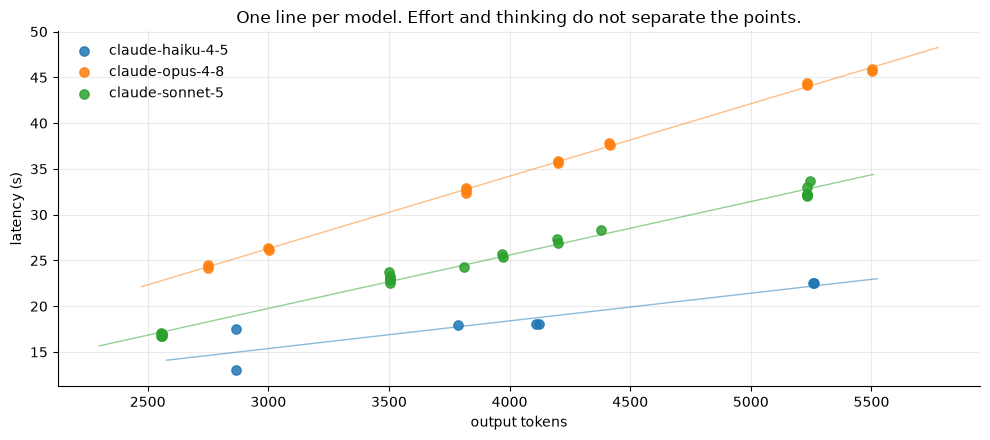

In [4]:
lat = analyze.load_latency()
fits = analyze.throughput(lat)
display(fits.round(2))

fig, ax = plt.subplots()
for model, g in lat.groupby("model"):
    ax.scatter(g["outputTokens"], g["ms"]/1000, label=model, s=45, alpha=.85, zorder=3)
    r = fits[fits["model"] == model]
    if not r.empty:
        xs = np.linspace(g["outputTokens"].min()*.9, g["outputTokens"].max()*1.05, 50)
        ys = [analyze.predict_ms(x, model, fits)/1000 for x in xs]
        ax.plot(xs, ys, lw=1, alpha=.5)
ax.set_xlabel("output tokens"); ax.set_ylabel("latency (s)")
ax.set_title("One line per model. Effort and thinking do not separate the points.")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


In [5]:
# Did `effort` or `thinking` do anything measurable?
by_cfg = (lat.groupby(["config", "anchor"])
            .agg(med_ms=("ms", "median"), med_out=("outputTokens", "median"),
                 thought=("thought", "any"), n=("ms", "size"))
            .reset_index().sort_values(["anchor", "med_ms"]))
display(by_cfg.round(0))
print("\n`thought` is False everywhere: a forced tool_choice already suppresses")
print("adaptive thinking, so the A2 hypothesis was answered by observation.")


,config,anchor,med_ms,med_out,thought,n
0,haiku45/nothink,index,17533.0,2867.0,False,3
6,sonnet5/default,index,19802.0,3032.0,False,4
8,sonnet5/low,index,19882.0,3032.0,False,4
10,sonnet5/low+nothink,index,19908.0,3030.0,False,4
4,opus48/low+nothink,index,24476.0,2749.0,False,3
2,opus48/default,index,29526.0,3410.0,False,4
1,haiku45/nothink,snippet,20279.0,4690.0,False,4
11,sonnet5/low+nothink,snippet,28902.0,4602.0,False,4
9,sonnet5/low,snippet,29960.0,4716.0,False,4
7,sonnet5/default,snippet,30188.0,4806.0,False,4



`thought` is False everywhere: a forced tool_choice already suppresses
adaptive thinking, so the A2 hypothesis was answered by observation.


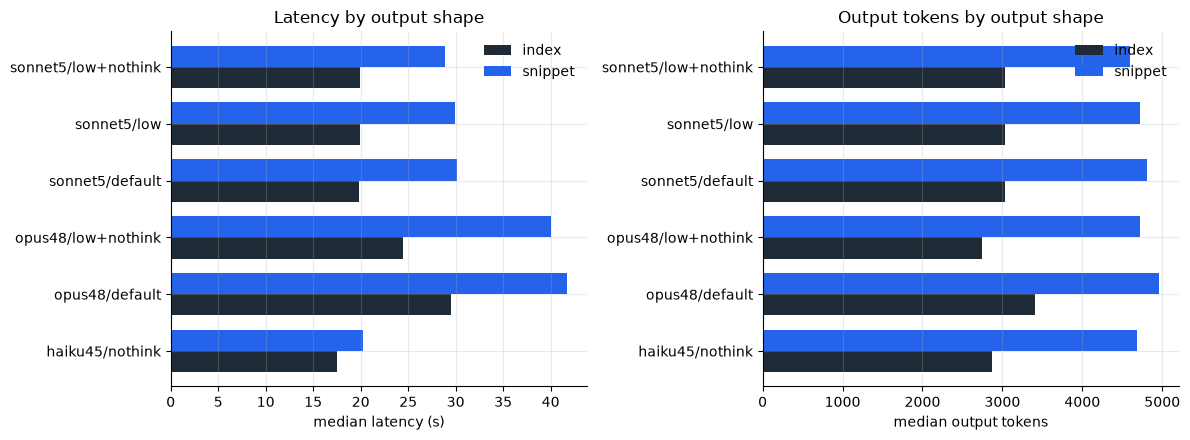

config
haiku45/nothink         2.7
opus48/default         12.2
opus48/low+nothink     15.5
sonnet5/default        10.4
sonnet5/low            10.1
sonnet5/low+nothink     9.0


In [6]:
# The anchor is the lever. Same model, same page, different output shape.
piv = lat.pivot_table(index="config", columns="anchor", values="ms", aggfunc="median")/1000
out = lat.pivot_table(index="config", columns="anchor", values="outputTokens", aggfunc="median")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
piv.plot(kind="barh", ax=a1, color=[INK, ACCENT], width=.75)
a1.set_xlabel("median latency (s)"); a1.set_ylabel(""); a1.set_title("Latency by output shape")
a1.legend(frameon=False, title="")
out.plot(kind="barh", ax=a2, color=[INK, ACCENT], width=.75)
a2.set_xlabel("median output tokens"); a2.set_ylabel(""); a2.set_title("Output tokens by output shape")
a2.legend(frameon=False, title="")
plt.tight_layout(); plt.show()

print((piv["snippet"] - piv["index"]).round(1).to_string())


## 3. Accuracy, in three columns that are never averaged

- **agreement** with the accepted reports in `data/reports` — the incumbent's
  *output*, not truth, so a disagreement is a case to adjudicate;
- **fabrications** — values printed nowhere on the page. Objective, and
  disqualifying;
- **range integrity** — the named check: a reference range that lost its
  separator (`4,11-5,60` → `4,115,60`) is a plausible wrong number, not a
  parse error.


In [7]:
acc = analyze.load_accuracy()
if acc.empty:
    print("accuracy.jsonl not written yet — run `npm run bench:accuracy`")
else:
    summary = (acc.groupby("component")
                 .agg(out_tokens=("outputTokens", "sum"),
                      rows=("armRows", "sum"),
                      baseline=("baselineRows", "sum"),
                      matched=("matched", "sum"),
                      missing=("n_missing", "sum"),
                      extra=("n_extra", "sum"),
                      value_delta=("n_valueMismatch", "sum"),
                      range_delta=("n_rangeMismatch", "sum"),
                      fabrications=("n_fabrications", "sum"),
                      collapsed=("n_collapsedRanges", "sum"))
                 .reset_index())
    display(summary)


,component,out_tokens,rows,baseline,matched,missing,extra,value_delta,range_delta,fabrications,collapsed
0,haiku45/columnmap,3890,142,154,114,40,28,2,114,0,0
1,haiku45/index,12023,142,154,142,12,0,1,0,0,0
2,opus48/index,11944,153,154,153,1,0,7,0,0,0
3,sonnet5/columnmap,5068,141,154,121,33,20,1,121,0,0
4,sonnet5/index,11173,142,154,142,12,0,1,0,6,0
5,sonnet5/snippet,18123,153,154,153,1,0,9,0,6,0


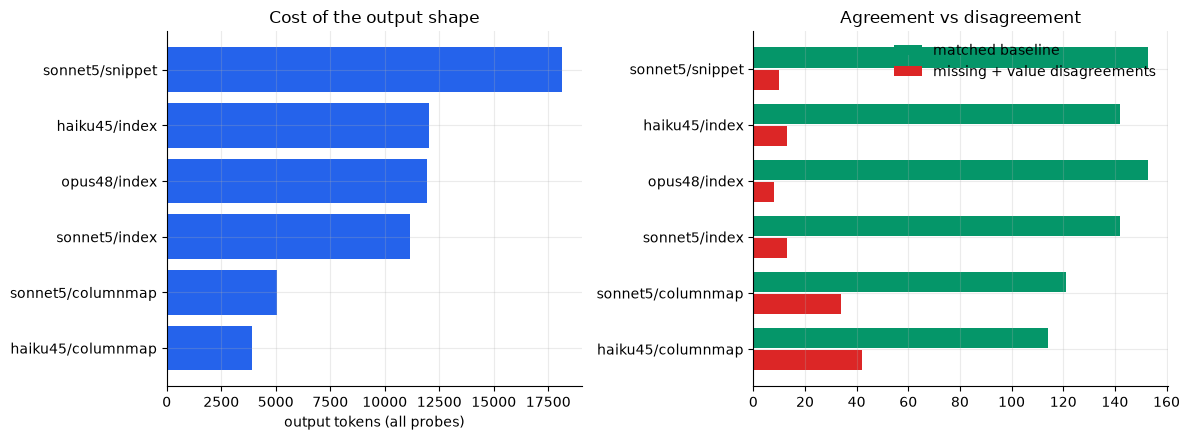

In [8]:
if not acc.empty:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
    s = summary.sort_values("out_tokens")
    a1.barh(s["component"], s["out_tokens"], color=ACCENT)
    a1.set_xlabel("output tokens (all probes)"); a1.set_title("Cost of the output shape")

    idx = np.arange(len(s))
    a2.barh(idx + .2, s["matched"], height=.36, color=GOOD, label="matched baseline")
    a2.barh(idx - .2, s["missing"] + s["value_delta"], height=.36, color=WARN,
            label="missing + value disagreements")
    a2.set_yticks(idx); a2.set_yticklabels(s["component"])
    a2.set_title("Agreement vs disagreement"); a2.legend(frameon=False)
    plt.tight_layout(); plt.show()


## 4. What the doctor actually waits for

The metric that matters is not seconds per page — it is **wall-clock for a
10-file batch**. That is `pages / concurrency` waves of one page each, where a
page costs the slower of its readers.


,scenario,page_s,batch_s
0,"A0 deployed (snippet, 2 readers, serial)",40.7,977.5
1,"A3 row_index, 2 readers, serial",26.3,631.2
2,"A4 row_index, Sonnet only, serial",19.9,478.4
3,"A4+ row_index, Sonnet only, concurrency 6",19.9,79.7


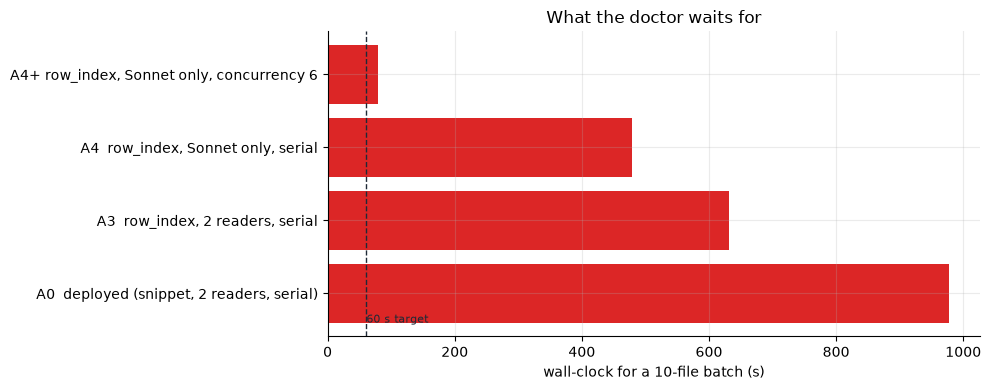

In [9]:
PAGES_10_FILES = 24  # 15 samples average 2.4 pages each

def arm_page_ms(readers, fits, out_tokens):
    """A page costs the slowest reader, since readers run concurrently."""
    return max(analyze.predict_ms(out_tokens.get(m, 2500), m, fits) for m in readers)

scenarios = []
if not lat.empty:
    med = lat.groupby(["model", "anchor"])["outputTokens"].median()
    def tok(m, a): return float(med.get((m, a), 2500))

    scenarios = [
        ("A0  deployed (snippet, 2 readers, serial)",
         ["claude-sonnet-5", "claude-opus-4-8"], "snippet", 1),
        ("A3  row_index, 2 readers, serial",
         ["claude-sonnet-5", "claude-opus-4-8"], "index", 1),
        ("A4  row_index, Sonnet only, serial",
         ["claude-sonnet-5"], "index", 1),
        ("A4+ row_index, Sonnet only, concurrency 6",
         ["claude-sonnet-5"], "index", 6),
    ]
    rows = []
    for label, models, anchor, conc in scenarios:
        page_ms = max(analyze.predict_ms(tok(m, anchor), m, fits) for m in models)
        rows.append({"scenario": label, "page_s": page_ms/1000,
                     "batch_s": analyze.batch_seconds(page_ms, PAGES_10_FILES, conc)})
    batch = pd.DataFrame(rows)
    display(batch.round(1))

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = [WARN if b > 60 else GOOD for b in batch["batch_s"]]
    ax.barh(batch["scenario"], batch["batch_s"], color=colors)
    ax.axvline(60, color=INK, ls="--", lw=1)
    ax.text(61, -.4, "60 s target", fontsize=8, color=INK)
    ax.set_xlabel("wall-clock for a 10-file batch (s)")
    ax.set_title("What the doctor waits for")
    plt.tight_layout(); plt.show()


## 5. Pages that should never have been sent

Stage 0 found that three of fifteen files route their **final page** to the
vision path — and every one of those pages carries **zero measurement rows**.
They are footer/signature pages. The demo renders each at 220 DPI and sends it
to two vision models to be told there is nothing there.


In [10]:
empty = floor[~floor["allPagesHaveText"]][["file", "pages", "rowCount"]].copy()
# Sample filenames encode blood-draw dates and samples/ is gitignored for
# that reason, so the corpus is shown by index in anything committed.
empty["file"] = [f"file{i+1:02d}.pdf" for i in empty.index]
print("files with a page that falls off the text path:")
display(empty)
print(f"\n{len(empty)}/{len(floor)} files = {len(empty)/len(floor):.0%} of a batch")
print("On a 10-file batch that is ~2 wasted vision round-trips on the critical path.")


files with a page that falls off the text path:


,file,pages,rowCount
5,file06.pdf,3.0,101.0
8,file09.pdf,3.0,111.0
9,file10.pdf,3.0,109.0



3/15 files = 20% of a batch
On a 10-file batch that is ~2 wasted vision round-trips on the critical path.


## 6. Two arms that returned integers instead of text

**A9 — column map.** The model returns which cell index holds name/value/unit/range
plus the list of measurement rows; the client rebuilds every value out of its own
`rows` array. Because no text comes back, a fabricated value is *unrepresentable*
rather than merely detectable.

**A10 — x-position columns.** No model at all: cluster cell left-edges into
columns and assign roles from what each column contains.


In [11]:
x = analyze._load("xcolumns.jsonl")
if not x.empty:
    for c in ("missing","extra","valueMismatch","unitMismatch","rangeMismatch","fabrications"):
        x[f"n_{c}"] = x[c].apply(len)
    tot = dict(pages=len(x), rows=x["armRows"].sum(), base=x["baselineRows"].sum(),
               matched=x["matched"].sum(), missing=x["n_missing"].sum(),
               extra=x["n_extra"].sum(), value=x["n_valueMismatch"].sum(),
               fab=x["n_fabrications"].sum(), ms=x["ms"].sum())
    print("A10 — deterministic x-position columns, all 32 text pages")
    for k, v in tot.items():
        print(f"  {k:<10}{v}")
    print(f"\n  recall {tot['matched']/tot['base']:.0%} of baseline rows, "
          f"at {tot['ms']/tot['pages']:.2f} ms/page and $0.00")
    print("  -> infinitely fast, and not accurate enough to ship.")


A10 — deterministic x-position columns, all 32 text pages
  pages     32
  rows      733
  base      878
  matched   536
  missing   342
  extra     197
  value     23
  fab       0
  ms        5.598586000000012

  recall 61% of baseline rows, at 0.17 ms/page and $0.00
  -> infinitely fast, and not accurate enough to ship.


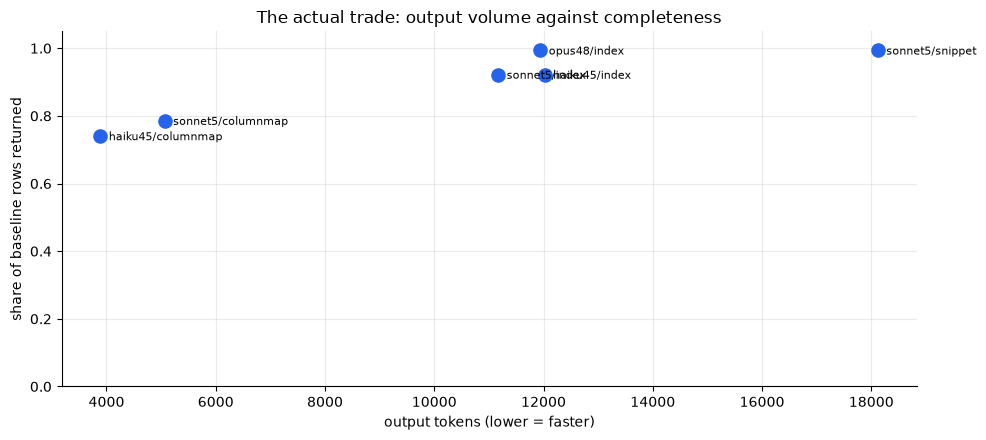

The column-map arms sit bottom-left: much cheaper output, materially
fewer rows returned. That is the decision, not a free win.


In [12]:
if not acc.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    s = summary.sort_values("out_tokens")
    recall = s["matched"] / s["baseline"]
    ax.scatter(s["out_tokens"], recall, s=90, color=ACCENT, zorder=3)
    for _, r in s.iterrows():
        ax.annotate(r["component"], (r["out_tokens"], r["matched"]/r["baseline"]),
                    fontsize=8, xytext=(6, -3), textcoords="offset points")
    ax.set_xlabel("output tokens (lower = faster)")
    ax.set_ylabel("share of baseline rows returned")
    ax.set_ylim(0, 1.05)
    ax.set_title("The actual trade: output volume against completeness")
    plt.tight_layout(); plt.show()
    print("The column-map arms sit bottom-left: much cheaper output, materially")
    print("fewer rows returned. That is the decision, not a free win.")


## 7. Measured: ten files, end to end

Everything above is per page. This is the wait.


,scenario,label,files,pages,concurrency,batch_s,first_s,p50_s,p95_s,costUsd
0,A4h,"row_index, Haiku 4.5 only",10,21,4,70.0,6.4,10.8,24.1,0.28
1,A5,"row_index, Sonnet 5 + Haiku 4.5",10,21,4,85.4,6.3,16.6,20.9,1.07
2,A5,"row_index, Sonnet 5 + Haiku 4.5",10,21,8,43.6,6.5,16.6,20.9,1.06


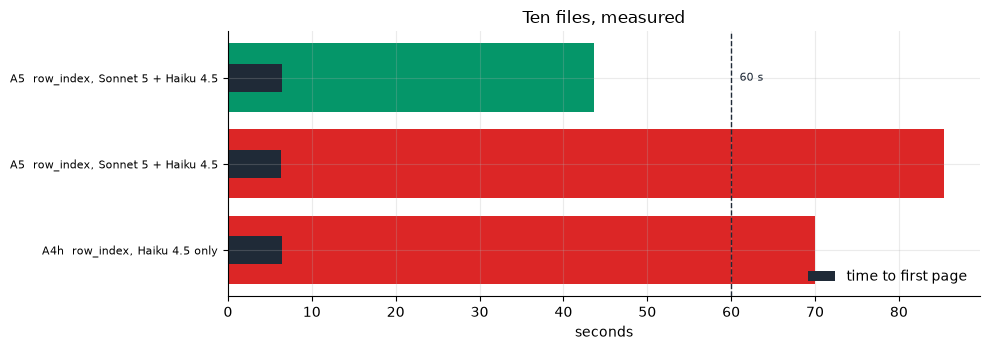

In [13]:
batch = analyze._load("batch.jsonl")
if batch.empty:
    print("batch.jsonl not written yet — run `npm run bench:batch`")
else:
    b = batch.copy()
    b["batch_s"] = b["totalMs"]/1000
    b["first_s"] = b["firstPageMs"]/1000
    b["p50_s"] = b["pageP50Ms"]/1000
    b["p95_s"] = b["pageP95Ms"]/1000
    display(b[["scenario","label","files","pages","concurrency",
               "batch_s","first_s","p50_s","p95_s","costUsd"]].round(2))

    fig, ax = plt.subplots(figsize=(10, 3.6))
    y = np.arange(len(b))
    ax.barh(y, b["batch_s"], color=[GOOD if v < 60 else WARN for v in b["batch_s"]])
    ax.barh(y, b["first_s"], color=INK, height=.32, label="time to first page")
    ax.set_yticks(y); ax.set_yticklabels(b["scenario"] + "  " + b["label"], fontsize=8)
    ax.axvline(60, color=INK, ls="--", lw=1)
    ax.text(61, y[-1], "60 s", fontsize=8, color=INK, va="center")
    ax.set_xlabel("seconds"); ax.set_title("Ten files, measured")
    ax.legend(frameon=False, loc="lower right")
    plt.tight_layout(); plt.show()
